# Generete 2D and 3D Model of Human

This is the main code accompanying the report "Predicting Body Segment Properties".
It estimates the mass and inertial properties of body segments for a procedurally generated human model.
The code outputs:

Printed values of the estimated parameters

A 2D visual plot of the generated person

Exported files required to visualize a 3D model in any URDF-compatible viewer.


In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
from anthromass.mass.massmain_module import *
from anthromass.prediction_module import *
from anthromass.anthro_module import *
from anthromass.mass.massmesh_module import *
from anthromass.mass.measurements_heights_module import *
from anthromass.mass.massurdf_module import *
import pandas as pd

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


✅ Meshes exported to c:\Users\sanna\Desktop\kandidat\bsp_estimation\anthromass\anthromass\mass\model_output


Below the main function for estimation of a person is estimated.  

 Uses estimated measurements from the anthropometry regression based on height, mass and gender and feeds it to main function which provides estimations and 2D plot. In this function the kind of model can be changed. 'xgboost', 'bambi_c' or 'bambi'.

In [9]:
def make_a_human(height:float, weight:float, gender:int):
    measurements=measurement_names()
    person = pd.DataFrame([{'weightkg': weight,'stature': height,'Gender': gender}])
    kindofmodel='bambi_c'
    df = loop_measurements(kindofmodel,measurements, person)
    main(df, weight, height, gender)

Change the input values below to estimate your human!

Inputs:  
make_a_human(height, weight, gender)  
* height in mm  
* weight in kg  
* gender, 0 for female, 1 for male.

Estimated paramaters for mass, COM positions, join center positions and moments of inertia are shown below. 

..............................................................................................................
RESULTS:
Estimated Height: 1.7709479932618593 m
Actual Height: 1.76 m
Total Estimated Weight (kg) using Clauser regression model: 88.35953111460489 kg
Total Estimated Weight using Zatriosky regression model: 87.15112 kg
..............................................................................................................

Center of mass positions:

    Head Upper Trunk Middle Trunk Lower Trunk Upper Arm Lower Arm   Hand  Thigh  Shank   Foot
X      0           0            0           0         0         0      0      0      0  0.143
Y      0           0            0           0     0.209     0.209  0.209  0.074  0.074  0.074
Z  1.648       1.368         1.18       0.979     1.279     0.998  0.791  0.723   0.32  0.037
..............................................................................................................

Joint center positions:

  Shoulder  Elbow

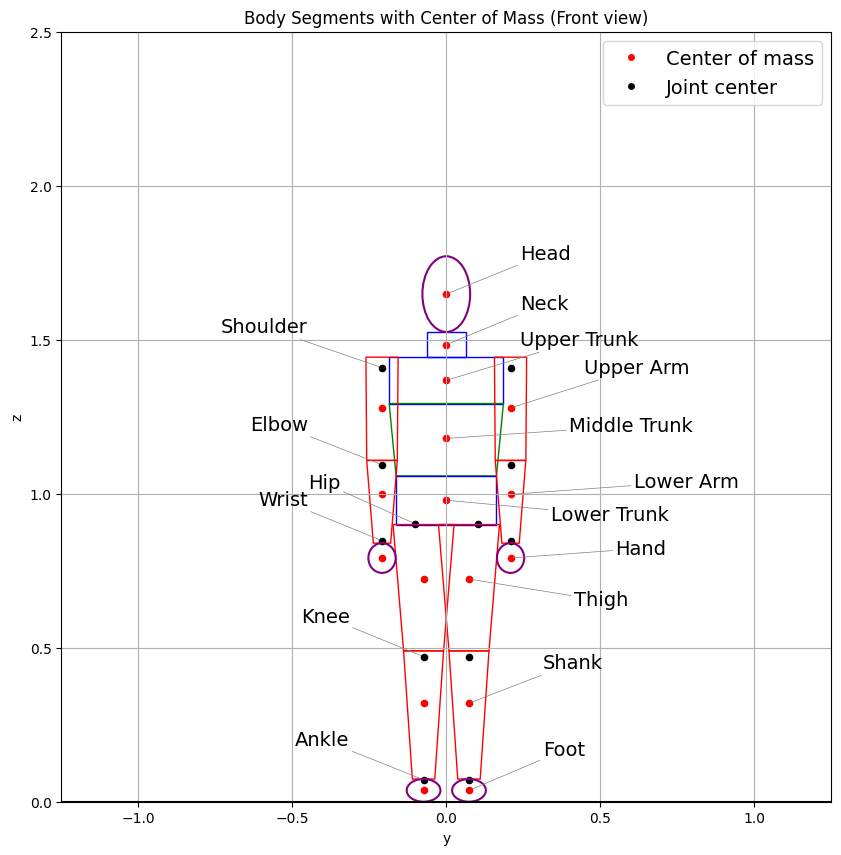

In [10]:
make_a_human(1760,86,1)

Below function for generating meshes and urdf files. Uses the same estimated measurments.

In [11]:
def generate_urdf_files(height:float, weight:float, gender:int):
    # 1) get the *raw* ANSUR row back out of your prediction
    measurements=measurement_names()
    persondf = pd.DataFrame([{'weightkg': weight,'stature': height,'Gender': gender}])
    kindofmodel = 'bambi_c'
    person = loop_measurements(kindofmodel,measurements, persondf)

    # 2) compute just once for the meshes
    meas = get_measurements(person, height)

    # 3) write all the .stl’s
    generate_all_meshes(meas, height)
    print("Done")
    # 4) write the .urdf from the *raw* row, so it can call get_measurements again
    create_urdf(person, height)


Change the input values below to estimate a 3D model of your human!

Inputs:  
make_a_human(height, weight, gender)  
* height in mm  
* weight in kg  
* gender, 0 for female, 1 for male.

In [12]:
generate_urdf_files(1760,86,1)

✅ Meshes exported to c:\Users\sanna\Desktop\kandidat\bsp_estimation\anthromass\anthromass\mass\model_output
Done
✅ URDF written


Above is the direction of where meshes and urdf files are stored on your computer. Drag all these generated files into a compatible URDF viewer to see your human.